In [1]:
!ls

sample_data


In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

In [3]:
# ============================================================
# 1️⃣ Device Configuration
# ============================================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [4]:
# ============================================================
# 2️⃣ Data Loading & Normalization [-1, 1]
# ============================================================

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5),
                         (0.5, 0.5, 0.5))  # Scale images to [-1,1]
])

train_dataset = datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)


100%|██████████| 170M/170M [04:03<00:00, 701kB/s]


In [5]:
# ============================================================
# 3️⃣ Encoder–Decoder CNN Model
# ============================================================

class EncoderDecoderCNN(nn.Module):
    def __init__(self):
        super(EncoderDecoderCNN, self).__init__()

        # -------- Encoder --------
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=4, stride=2, padding=1),
            nn.ReLU(inplace=True),

            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1),
            nn.ReLU(inplace=True)
        )

        # -------- Decoder --------
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),
            nn.ReLU(inplace=True),

            nn.ConvTranspose2d(64, 3, kernel_size=4, stride=2, padding=1),
            nn.Tanh()  # Output in [-1,1]
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x


model = EncoderDecoderCNN().to(device)
print("Model Initialized Successfully")



Model Initialized Successfully


In [6]:
# ============================================================
# 4️⃣ Loss Functions & Optimizer
# ============================================================

mse_loss_fn = nn.MSELoss()
l1_loss_fn = nn.L1Loss()

optimizer = optim.Adam(model.parameters(), lr=0.0002)


In [7]:
# ============================================================
# 5️⃣ Training Loop
# ============================================================

epochs = 30
mse_losses = []
l1_losses = []

for epoch in range(epochs):
    model.train()
    total_mse = 0.0
    total_l1 = 0.0

    for images, _ in train_loader:
        images = images.to(device)

        outputs = model(images)

        mse_loss = mse_loss_fn(outputs, images)
        l1_loss = l1_loss_fn(outputs, images)

        optimizer.zero_grad()
        mse_loss.backward()
        optimizer.step()

        total_mse += mse_loss.item()
        total_l1 += l1_loss.item()

    avg_mse = total_mse / len(train_loader)
    avg_l1 = total_l1 / len(train_loader)

    mse_losses.append(avg_mse)
    l1_losses.append(avg_l1)

    print(f"Epoch [{epoch+1}/{epochs}] "
          f"| MSE: {avg_mse:.4f} "
          f"| L1: {avg_l1:.4f}")



Epoch [1/30] | MSE: 0.0194 | L1: 0.0907
Epoch [2/30] | MSE: 0.0046 | L1: 0.0499
Epoch [3/30] | MSE: 0.0031 | L1: 0.0409
Epoch [4/30] | MSE: 0.0024 | L1: 0.0356
Epoch [5/30] | MSE: 0.0020 | L1: 0.0320
Epoch [6/30] | MSE: 0.0017 | L1: 0.0293
Epoch [7/30] | MSE: 0.0014 | L1: 0.0271
Epoch [8/30] | MSE: 0.0013 | L1: 0.0253
Epoch [9/30] | MSE: 0.0011 | L1: 0.0239
Epoch [10/30] | MSE: 0.0010 | L1: 0.0226
Epoch [11/30] | MSE: 0.0009 | L1: 0.0216
Epoch [12/30] | MSE: 0.0009 | L1: 0.0207
Epoch [13/30] | MSE: 0.0008 | L1: 0.0199
Epoch [14/30] | MSE: 0.0008 | L1: 0.0193
Epoch [15/30] | MSE: 0.0007 | L1: 0.0186
Epoch [16/30] | MSE: 0.0007 | L1: 0.0181
Epoch [17/30] | MSE: 0.0006 | L1: 0.0176
Epoch [18/30] | MSE: 0.0006 | L1: 0.0172
Epoch [19/30] | MSE: 0.0006 | L1: 0.0167
Epoch [20/30] | MSE: 0.0005 | L1: 0.0163
Epoch [21/30] | MSE: 0.0005 | L1: 0.0160
Epoch [22/30] | MSE: 0.0005 | L1: 0.0156
Epoch [23/30] | MSE: 0.0005 | L1: 0.0154
Epoch [24/30] | MSE: 0.0005 | L1: 0.0151
Epoch [25/30] | MSE: 0.00

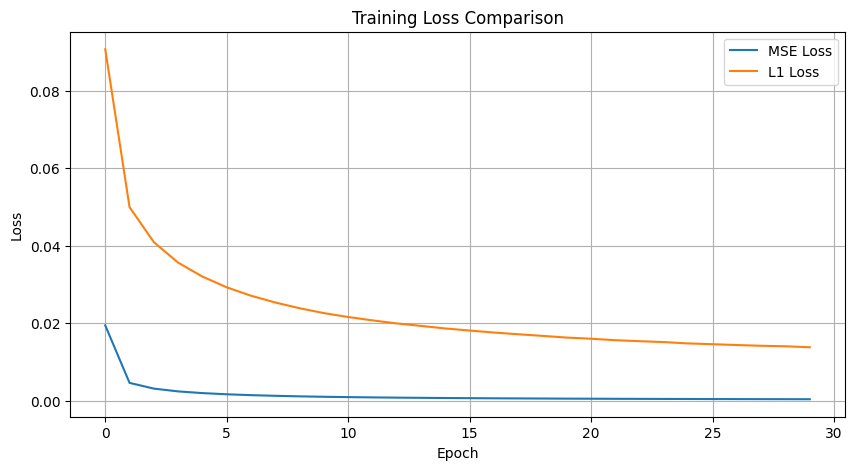

In [8]:

# ============================================================
# 6️⃣ Plot Training Loss
# ============================================================

plt.figure(figsize=(10,5))
plt.plot(mse_losses, label="MSE Loss")
plt.plot(l1_losses, label="L1 Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Comparison")
plt.legend()
plt.grid(True)
plt.show()

In [9]:
# ============================================================
# 7️⃣ Evaluate on Test Dataset
# ============================================================

model.eval()
test_mse = 0.0
test_l1 = 0.0

with torch.no_grad():
    for images, _ in test_loader:
        images = images.to(device)
        outputs = model(images)

        test_mse += mse_loss_fn(outputs, images).item()
        test_l1 += l1_loss_fn(outputs, images).item()

avg_test_mse = test_mse / len(test_loader)
avg_test_l1 = test_l1 / len(test_loader)

print("\nTest Results:")
print(f"Test MSE: {avg_test_mse:.4f}")
print(f"Test L1: {avg_test_l1:.4f}")



Test Results:
Test MSE: 0.0004
Test L1: 0.0130


In [10]:
# ============================================================
# 8️⃣ Visualization Section
# ============================================================

def denormalize(img):
    img = img * 0.5 + 0.5
    return img.clamp(0, 1)

model.eval()
with torch.no_grad():
    sample_images, _ = next(iter(test_loader))
    sample_images = sample_images.to(device)
    reconstructed = model(sample_images)

sample_images = denormalize(sample_images.cpu())
reconstructed = denormalize(reconstructed.cpu())

difference = torch.abs(sample_images - reconstructed)


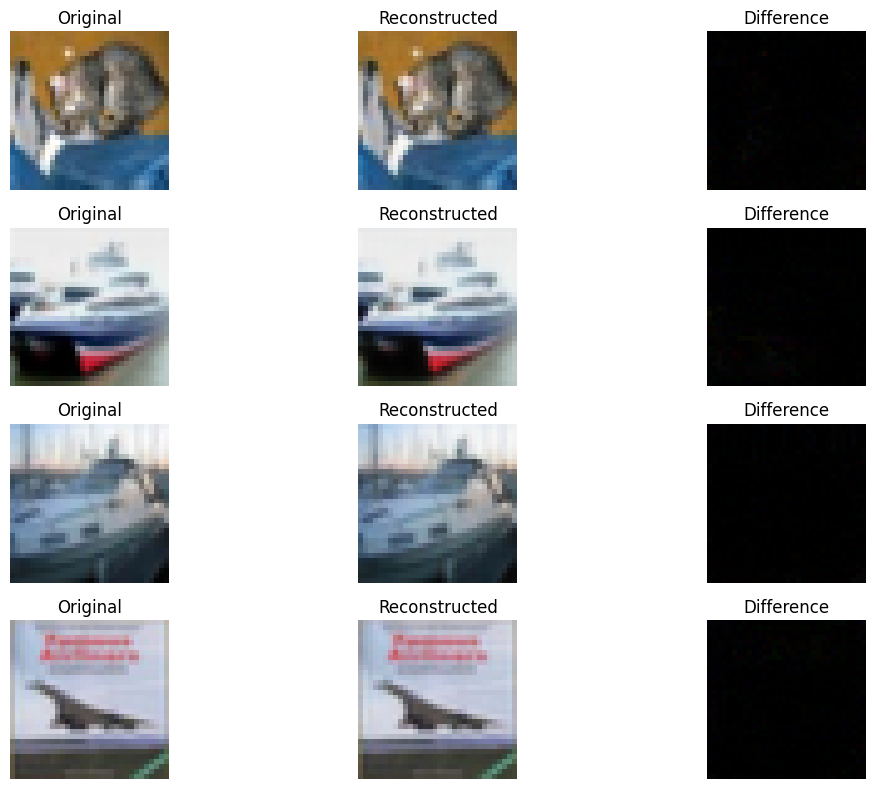

In [11]:
# ============================================================
# 9️⃣ Show Original vs Reconstructed vs Difference
# ============================================================

n = 4
plt.figure(figsize=(12,8))

for i in range(n):
    # Original
    plt.subplot(n,3,3*i+1)
    plt.imshow(np.transpose(sample_images[i], (1,2,0)))
    plt.title("Original")
    plt.axis("off")

    # Reconstructed
    plt.subplot(n,3,3*i+2)
    plt.imshow(np.transpose(reconstructed[i], (1,2,0)))
    plt.title("Reconstructed")
    plt.axis("off")

    # Difference Map
    plt.subplot(n,3,3*i+3)
    plt.imshow(np.transpose(difference[i], (1,2,0)))
    plt.title("Difference")
    plt.axis("off")

plt.tight_layout()
plt.show()

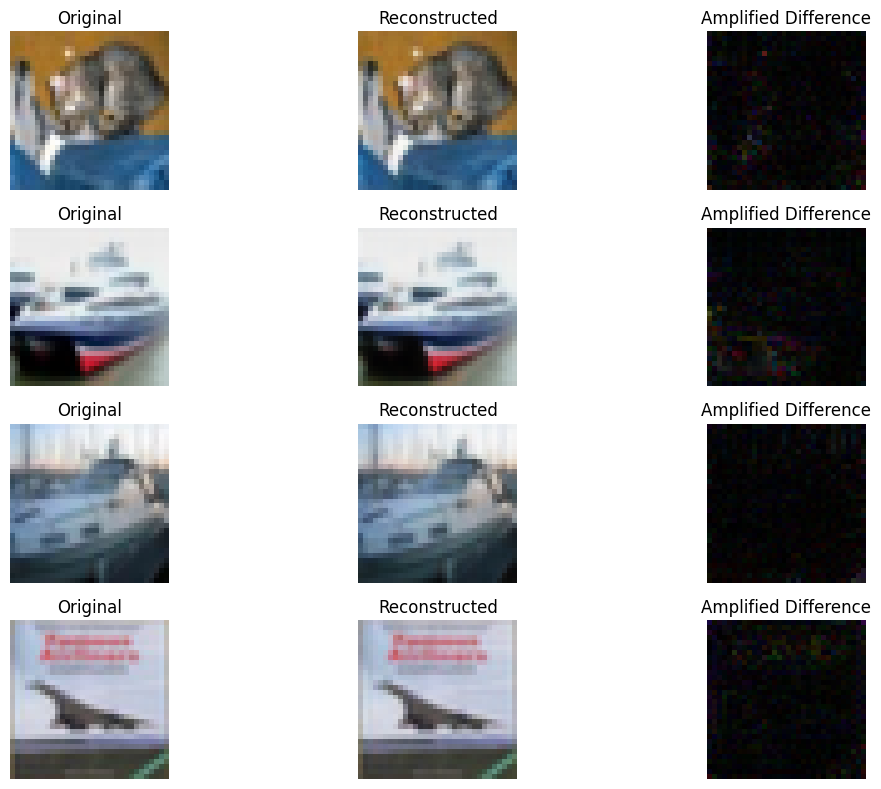

In [12]:
difference = torch.abs(sample_images - reconstructed)

# Amplify difference for visualization
difference = difference * 5   # Try 5 or 10

plt.figure(figsize=(12,8))

for i in range(4):
    plt.subplot(4,3,3*i+1)
    plt.imshow(np.transpose(sample_images[i], (1,2,0)))
    plt.title("Original")
    plt.axis("off")

    plt.subplot(4,3,3*i+2)
    plt.imshow(np.transpose(reconstructed[i], (1,2,0)))
    plt.title("Reconstructed")
    plt.axis("off")

    plt.subplot(4,3,3*i+3)
    plt.imshow(np.transpose(difference[i], (1,2,0)))
    plt.title("Amplified Difference")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [14]:
# ============================================================
# 3️⃣ Generator (Encoder–Decoder)
# ============================================================

class Generator(nn.Module):
    def __init__(self):
        super(Generator, self).__init__()

        self.encoder = nn.Sequential(
            nn.Conv2d(3, 64, 4, 2, 1),
            nn.LeakyReLU(0.2),

            nn.Conv2d(64, 128, 4, 2, 1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2)
        )

        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(128, 64, 4, 2, 1),
            nn.BatchNorm2d(64),
            nn.ReLU(),

            nn.ConvTranspose2d(64, 3, 4, 2, 1),
            nn.Tanh()
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x

In [15]:
# ============================================================
# 4️⃣ Discriminator
# ============================================================

class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()

        self.model = nn.Sequential(
            nn.Conv2d(3, 64, 4, 2, 1),
            nn.LeakyReLU(0.2),

            nn.Conv2d(64, 128, 4, 2, 1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2),

            nn.Flatten(),
            nn.Linear(128*8*8, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x)


In [16]:
# ============================================================
# 5️⃣ Initialize Models
# ============================================================

generator = Generator().to(device)
discriminator = Discriminator().to(device)

In [17]:
# ============================================================
# 6️⃣ Loss & Optimizers
# ============================================================

adversarial_loss = nn.BCELoss()
reconstruction_loss = nn.L1Loss()

optimizer_G = optim.Adam(generator.parameters(), lr=0.0002, betas=(0.5, 0.999))
optimizer_D = optim.Adam(discriminator.parameters(), lr=0.0002, betas=(0.5, 0.999))


In [18]:
# ============================================================
# 7️⃣ Training GAN
# ============================================================

epochs = 30
lambda_L1 = 100   # Weight for reconstruction loss

for epoch in range(epochs):

    for images, _ in train_loader:

        images = images.to(device)
        batch_size = images.size(0)

        real_labels = torch.ones(batch_size, 1).to(device)
        fake_labels = torch.zeros(batch_size, 1).to(device)

        # =====================
        # Train Discriminator
        # =====================

        optimizer_D.zero_grad()

        real_output = discriminator(images)
        d_real_loss = adversarial_loss(real_output, real_labels)

        fake_images = generator(images)
        fake_output = discriminator(fake_images.detach())
        d_fake_loss = adversarial_loss(fake_output, fake_labels)

        d_loss = (d_real_loss + d_fake_loss) / 2
        d_loss.backward()
        optimizer_D.step()

        # =====================
        # Train Generator
        # =====================

        optimizer_G.zero_grad()

        fake_output = discriminator(fake_images)

        g_adv_loss = adversarial_loss(fake_output, real_labels)
        g_recon_loss = reconstruction_loss(fake_images, images)

        g_loss = g_adv_loss + lambda_L1 * g_recon_loss
        g_loss.backward()
        optimizer_G.step()

    print(f"Epoch [{epoch+1}/{epochs}] "
          f"| D Loss: {d_loss.item():.4f} "
          f"| G Loss: {g_loss.item():.4f}")

Epoch [1/30] | D Loss: 0.2718 | G Loss: 10.8246
Epoch [2/30] | D Loss: 0.2136 | G Loss: 12.4008
Epoch [3/30] | D Loss: 0.1192 | G Loss: 14.7675
Epoch [4/30] | D Loss: 0.2096 | G Loss: 11.1819
Epoch [5/30] | D Loss: 0.1962 | G Loss: 10.7032
Epoch [6/30] | D Loss: 0.3853 | G Loss: 13.8027
Epoch [7/30] | D Loss: 0.6082 | G Loss: 7.9648
Epoch [8/30] | D Loss: 0.4408 | G Loss: 9.0187
Epoch [9/30] | D Loss: 0.3418 | G Loss: 6.9694
Epoch [10/30] | D Loss: 0.6096 | G Loss: 7.0293
Epoch [11/30] | D Loss: 0.5021 | G Loss: 5.2615
Epoch [12/30] | D Loss: 0.3716 | G Loss: 5.9944
Epoch [13/30] | D Loss: 0.2761 | G Loss: 6.3643
Epoch [14/30] | D Loss: 0.6658 | G Loss: 4.6931
Epoch [15/30] | D Loss: 0.6010 | G Loss: 5.8113
Epoch [16/30] | D Loss: 0.3573 | G Loss: 5.8551
Epoch [17/30] | D Loss: 1.1738 | G Loss: 5.7108
Epoch [18/30] | D Loss: 0.3837 | G Loss: 12.4147
Epoch [19/30] | D Loss: 0.3222 | G Loss: 7.5748
Epoch [20/30] | D Loss: 0.2104 | G Loss: 6.3042
Epoch [21/30] | D Loss: 0.5059 | G Loss: 5

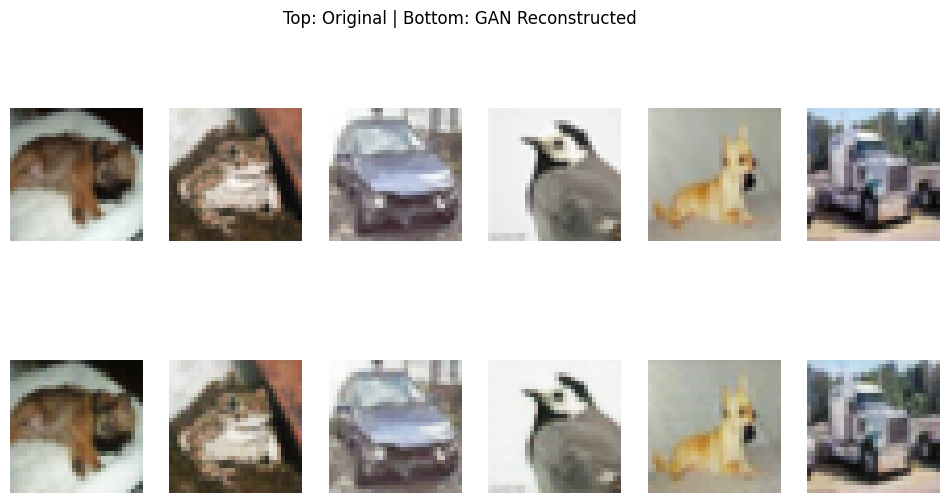

In [19]:
# ============================================================
# 8️⃣ Visualization
# ============================================================

def denormalize(img):
    img = img * 0.5 + 0.5
    return img.clamp(0, 1)

generator.eval()
with torch.no_grad():
    sample_images, _ = next(iter(train_loader))
    sample_images = sample_images.to(device)
    generated = generator(sample_images)

sample_images = denormalize(sample_images.cpu())
generated = denormalize(generated.cpu())

plt.figure(figsize=(12,6))

for i in range(6):
    plt.subplot(2,6,i+1)
    plt.imshow(np.transpose(sample_images[i], (1,2,0)))
    plt.axis("off")

    plt.subplot(2,6,i+7)
    plt.imshow(np.transpose(generated[i], (1,2,0)))
    plt.axis("off")

plt.suptitle("Top: Original | Bottom: GAN Reconstructed")
plt.show()

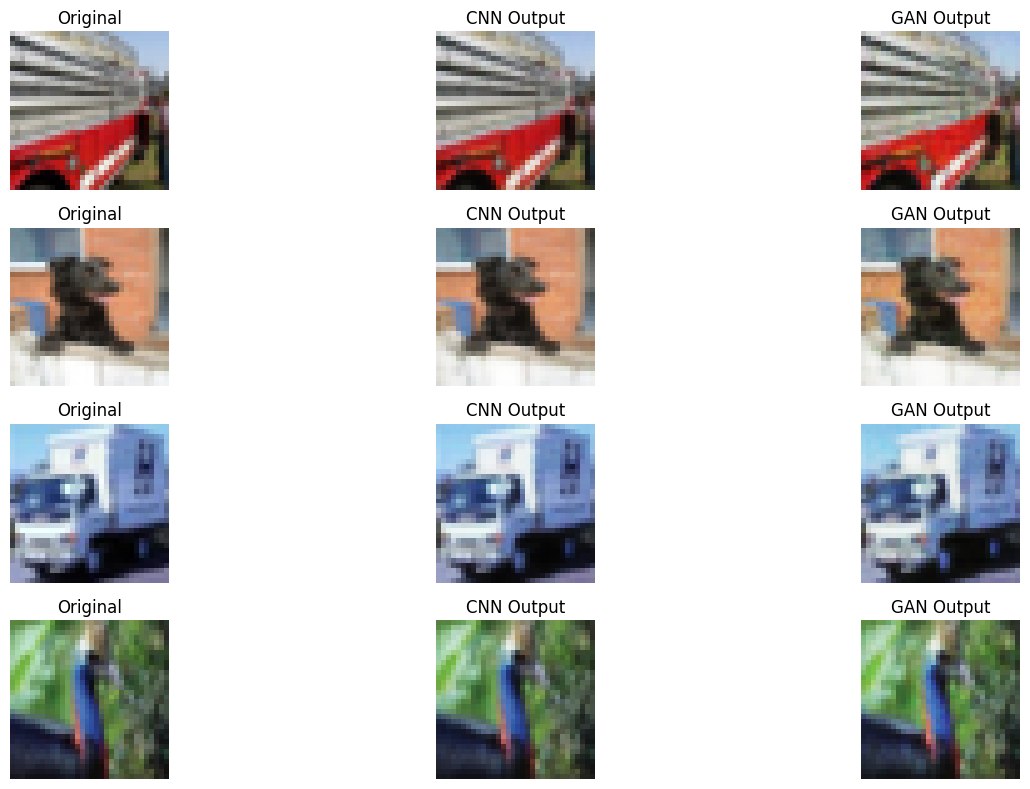

In [21]:
# ============================================================
# CNN vs GAN Visual Comparison
# ============================================================

def denormalize(img):
    img = img * 0.5 + 0.5
    return img.clamp(0, 1)

model.eval()
generator.eval()

with torch.no_grad():
    sample_images, _ = next(iter(train_loader))
    sample_images = sample_images.to(device)

    cnn_output = model(sample_images)
    gan_output = generator(sample_images)

sample_images = denormalize(sample_images.cpu())
cnn_output = denormalize(cnn_output.cpu())
gan_output = denormalize(gan_output.cpu())

plt.figure(figsize=(15,8))

n = 4
for i in range(n):

    # Original
    plt.subplot(n,3,3*i+1)
    plt.imshow(np.transpose(sample_images[i], (1,2,0)))
    plt.title("Original")
    plt.axis("off")

    # CNN Output
    plt.subplot(n,3,3*i+2)
    plt.imshow(np.transpose(cnn_output[i], (1,2,0)))
    plt.title("CNN Output")
    plt.axis("off")

    # GAN Output
    plt.subplot(n,3,3*i+3)
    plt.imshow(np.transpose(gan_output[i], (1,2,0)))
    plt.title("GAN Output")
    plt.axis("off")

plt.tight_layout()
plt.show()

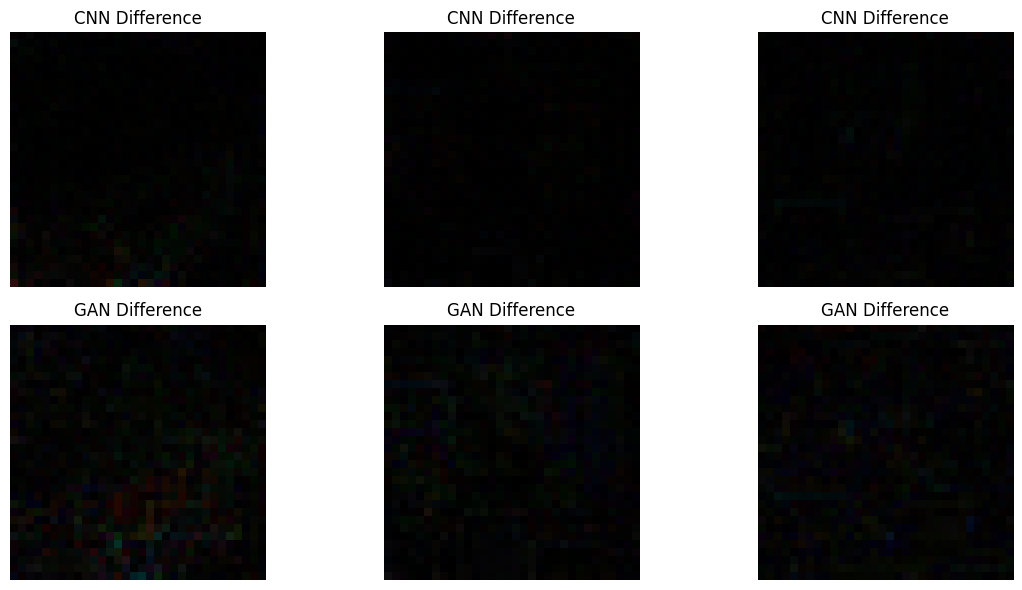

In [22]:
cnn_diff = torch.abs(sample_images - cnn_output)
gan_diff = torch.abs(sample_images - gan_output)

plt.figure(figsize=(12,6))

for i in range(3):

    # CNN Difference
    plt.subplot(2,3,i+1)
    plt.imshow(np.transpose(cnn_diff[i], (1,2,0)))
    plt.title("CNN Difference")
    plt.axis("off")

    # GAN Difference
    plt.subplot(2,3,i+4)
    plt.imshow(np.transpose(gan_diff[i], (1,2,0)))
    plt.title("GAN Difference")
    plt.axis("off")

plt.tight_layout()
plt.show()

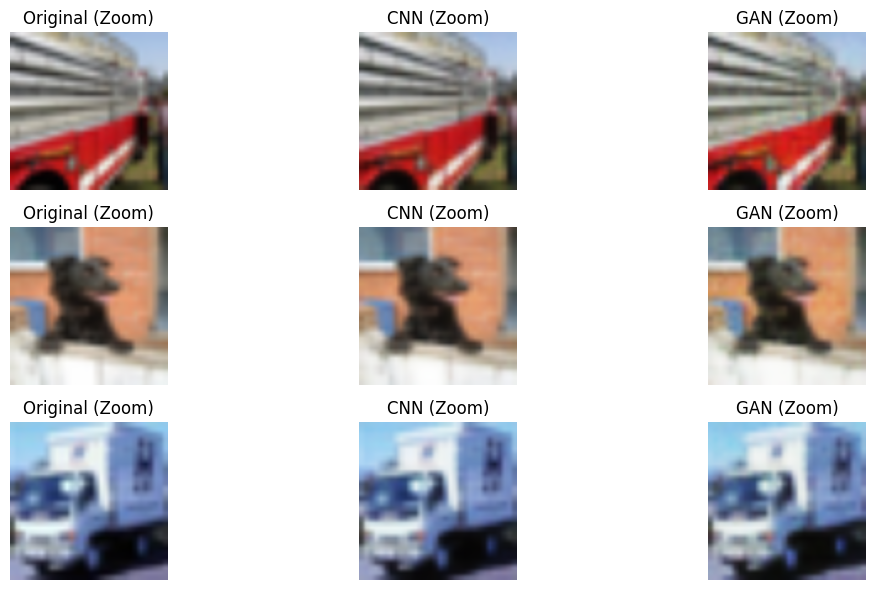

In [24]:
import torch.nn.functional as F

def upscale(img, scale=4):
    return F.interpolate(img, scale_factor=scale, mode='bilinear')

zoom_original = upscale(sample_images)
zoom_cnn = upscale(cnn_output)
zoom_gan = upscale(gan_output)

plt.figure(figsize=(12,6))

for i in range(3):
    plt.subplot(3,3,3*i+1)
    plt.imshow(np.transpose(zoom_original[i], (1,2,0)))
    plt.title("Original (Zoom)")
    plt.axis("off")

    plt.subplot(3,3,3*i+2)
    plt.imshow(np.transpose(zoom_cnn[i], (1,2,0)))
    plt.title("CNN (Zoom)")
    plt.axis("off")

    plt.subplot(3,3,3*i+3)
    plt.imshow(np.transpose(zoom_gan[i], (1,2,0)))
    plt.title("GAN (Zoom)")
    plt.axis("off")

plt.tight_layout()
plt.show()

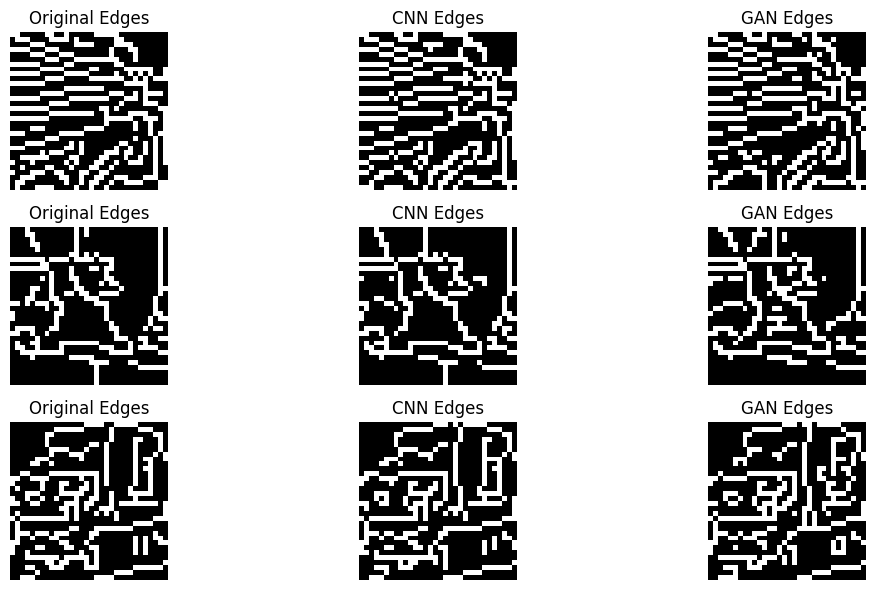

In [25]:
import cv2

def edge_map(img):
    img_np = np.transpose(img.numpy(), (1,2,0))
    img_gray = cv2.cvtColor(img_np, cv2.COLOR_RGB2GRAY)
    edges = cv2.Canny((img_gray*255).astype(np.uint8), 50, 150)
    return edges

plt.figure(figsize=(12,6))

for i in range(3):
    plt.subplot(3,3,3*i+1)
    plt.imshow(edge_map(sample_images[i]), cmap='gray')
    plt.title("Original Edges")
    plt.axis("off")

    plt.subplot(3,3,3*i+2)
    plt.imshow(edge_map(cnn_output[i]), cmap='gray')
    plt.title("CNN Edges")
    plt.axis("off")

    plt.subplot(3,3,3*i+3)
    plt.imshow(edge_map(gan_output[i]), cmap='gray')
    plt.title("GAN Edges")
    plt.axis("off")

plt.tight_layout()
plt.show()

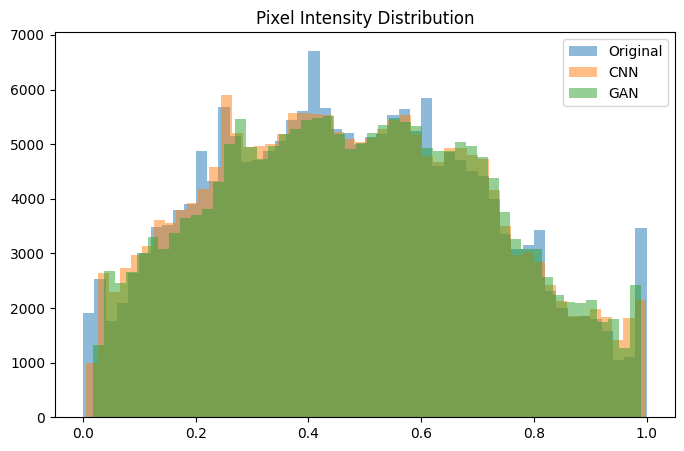

In [26]:
plt.figure(figsize=(8,5))

plt.hist(sample_images.flatten(), bins=50, alpha=0.5, label="Original")
plt.hist(cnn_output.flatten(), bins=50, alpha=0.5, label="CNN")
plt.hist(gan_output.flatten(), bins=50, alpha=0.5, label="GAN")

plt.legend()
plt.title("Pixel Intensity Distribution")
plt.show()